## Imports

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

## Load data

In [2]:
reviews_preprocessed = pd.read_csv("../data/processed/reviews_preprocessed.csv", index_col=0)
reviews_preprocessed = reviews_preprocessed.dropna(subset=["Text_clean"])

## Train/test split

The test set is held out here and touched **only once**, at the very end, for the final evaluation of the selected model. All model comparison and hyperparameter selection happens through cross-validation on the train set only (see below), avoiding the methodology issue from the earlier version of this notebook, where multiple configurations were compared by repeatedly checking `classification_report` on the test set.

In [3]:
X = reviews_preprocessed["Text_clean"]
y = reviews_preprocessed["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Pipeline + GridSearchCV

`TfidfVectorizer` and the classifier are combined into a single `Pipeline`. This matters for cross-validation specifically: if TF-IDF were fit once on the whole `X_train` before handing data to `GridSearchCV`, the IDF statistics (word frequencies across the corpus) would already reflect words from every fold, including the fold currently held out as validation within a given CV split. Wrapping both steps in a `Pipeline` makes `GridSearchCV` refit the vectorizer **separately for each fold**, on that fold's training portion only — so no information from a fold's validation portion leaks into its own training statistics.

The grid below compares two classifiers (Logistic Regression and LinearSVC) across n-gram range and regularization strength (`C`). `max_features` is fixed at 10,000 rather than re-tested, since the earlier manual comparison (04_model_improvements, first version) already showed diminishing returns beyond that point — reusing that finding keeps the grid a reasonable size instead of re-testing a dimension we already understand.

In [4]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000)),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))  # placeholder, overridden by param_grid
])

param_grid = [
    {
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "clf": [LogisticRegression(max_iter=1000, random_state=42)],
        "clf__C": [0.1, 1, 10],
    },
    {
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "clf": [LinearSVC(max_iter=1000, random_state=42)],
        "clf__C": [0.1, 1, 10],
    },
]

`cv=3` splits `X_train` into 3 folds internally — each configuration is trained on 2 folds and validated on the 3rd, three times over, and the scores are averaged. `scoring='f1_macro'` keeps the same metric used throughout the project. `n_jobs=-1` parallelizes across CPU cores.

This will take a while (36 total fits: 12 configurations × 3 folds) — that's expected given the dataset size.

In [5]:
grid_search = GridSearchCV(
    pipeline, param_grid, cv=3, scoring="f1_macro", n_jobs=-1, verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'clf': [LogisticRegre...ndom_state=42)], 'clf__C': [0.1, 1, ...], 'tfidf__ngram_range': [(1, ...), (1, ...)]}, {'clf': [LinearSVC(random_state=42)], 'clf__C': [0.1, 1, ...], 'tfidf__ngram_range': [(1, ...), (1, ...)]}]"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


## Best configuration found

`best_params_` shows the winning combination, and `best_score_` is the mean cross-validated F1 (macro) across the 3 folds for that combination — an estimate based only on train data, with the test set still completely untouched.

In [6]:
print("Best params:", grid_search.best_params_)
print("Best CV macro F1:", grid_search.best_score_)

Best params: {'clf': LinearSVC(random_state=42), 'clf__C': 1, 'tfidf__ngram_range': (1, 2)}
Best CV macro F1: 0.8836145821034987


## Final evaluation on the test set

This is the **only** time the test set is used for evaluation in this notebook. The best pipeline found by `GridSearchCV` (already refit on the full `X_train` automatically by `GridSearchCV` with `refit=True`, the default) is evaluated here once, giving an honest, unbiased estimate of how the selected model performs on unseen data.

In [7]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.76      0.81     16393
           1       0.96      0.98      0.97     88709

    accuracy                           0.94    105102
   macro avg       0.91      0.87      0.89    105102
weighted avg       0.94      0.94      0.94    105102



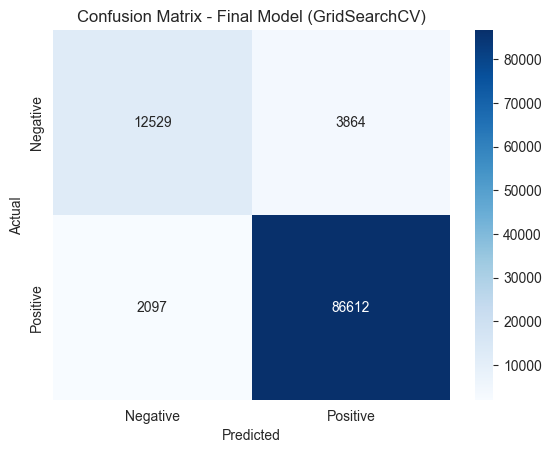

In [8]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final Model (GridSearchCV)")
plt.show()

## Save the final model

Saving the full pipeline (vectorizer + classifier together) so it can be reloaded and applied to new, raw text directly, without needing to separately re-fit or re-apply TF-IDF.

In [9]:
import os
os.makedirs("../models", exist_ok=True)
joblib.dump(best_model, "../models/sentiment_model.pkl")

['../models/sentiment_model.pkl']

## Summary

Replaced the earlier manual comparison approach (7 configurations, each evaluated by repeatedly checking the test set) with `Pipeline` + `GridSearchCV`. This addresses two issues in the original version of this notebook:

1. **Selection bias from repeated test-set checks** — the test set is now touched exactly once, for a single final evaluation, rather than being used to compare and choose between configurations.
2. **Cross-fold leakage risk** — wrapping `TfidfVectorizer` inside the `Pipeline` ensures it is refit independently on each cross-validation fold's training portion, rather than being fit once on the entire train set before folding.

**Result**: GridSearchCV selected LinearSVC (C=1) with bigrams — the same configuration found
manually in the earlier version of this notebook. Cross-validated macro F1 on train was 0.884,
and the final test macro F1 was 0.89 — closely matching the CV estimate, and identical to the
result obtained through manual comparison. This confirms the earlier manual selection was not
an artifact of repeated test-set peeking, though the rigorous process remains the methodologically
correct approach going forward.